# Lab 1 – Fuzzing Results Analysis

Analyses results from `run_fuzzing_lab.sh` across **random** and **smart** (hill climber) modes.

Expected directory layout (relative to the repo root):
```
fuzzing_results/
  random/  problem{N}.log  problem{N}_random_branches.csv  problem{N}_random_errors.csv
  smart/   problem{N}.log  problem{N}_smart_branches.csv   problem{N}_smart_errors.csv
```

In [1]:
import re
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Consistent style across all figures
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = {'random': '#2196F3', 'smart': '#F44336'}   # blue / red
LINESTYLES = {'random': '-', 'smart': '--'}

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Adjust RESULTS_ROOT if you run the notebook from a different working directory.
RESULTS_ROOT = Path('..') / 'fuzzing_results'
FIGURES_DIR  = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

PROBLEMS = [11, 12, 13, 14, 15, 17]
MODES    = ['random', 'smart']

print('Results root:', RESULTS_ROOT.resolve())
print('Figures dir :', FIGURES_DIR.resolve())

Results root: /Users/roham.koohestani/Desktop/Uni/Automated Software Testing and Reverse Engineering/repository/fuzzing_results
Figures dir : /Users/roham.koohestani/Desktop/Uni/Automated Software Testing and Reverse Engineering/repository/analysis/figures


## 1 – Load data

In [3]:
# ── Log parsing ───────────────────────────────────────────────────────────────

def parse_log(path: Path) -> dict:
    """Extract summary lines from a problem log file."""
    result = {
        'total_branches': None,
        'best_run_branches': None,
        'best_trace': None,
        'num_errors': None,
        'error_codes': [],
    }
    if not path.exists():
        return result
    text = path.read_text()
    m = re.search(r'Total unique branches visited: (\d+)', text)
    if m: result['total_branches'] = int(m.group(1))
    m = re.search(r'Max unique branches in a single trace: (\d+)', text)
    if m: result['best_run_branches'] = int(m.group(1))
    m = re.search(r'Best trace: (\[.*?\])', text)
    if m: result['best_trace'] = m.group(1)
    m = re.search(r'Triggered errors \((\d+)\): (\[.*?\])', text)
    if m:
        result['num_errors'] = int(m.group(1))
        codes = re.findall(r'error_\d+', m.group(2))
        result['error_codes'] = sorted(codes, key=lambda x: int(x.split('_')[1]))
    return result


# ── CSV loading ───────────────────────────────────────────────────────────────

def load_branches_csv(problem: int, mode: str) -> pd.DataFrame | None:
    path = RESULTS_ROOT / mode / f'problem{problem}_{mode}_branches.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df


def load_errors_csv(problem: int, mode: str) -> pd.DataFrame | None:
    path = RESULTS_ROOT / mode / f'problem{problem}_{mode}_errors.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    # Compute cumulative error count over time
    df = df.sort_values('elapsed_seconds').reset_index(drop=True)
    df['cumulative_errors'] = range(1, len(df) + 1)
    return df


# ── Build master data structures ──────────────────────────────────────────────

logs     = {}   # logs[(problem, mode)]     = dict from parse_log
branches = {}   # branches[(problem, mode)] = DataFrame or None
errors   = {}   # errors[(problem, mode)]   = DataFrame or None

for mode in MODES:
    for p in PROBLEMS:
        log_path = RESULTS_ROOT / mode / f'problem{p}.log'
        logs[(p, mode)]     = parse_log(log_path)
        branches[(p, mode)] = load_branches_csv(p, mode)
        errors[(p, mode)]   = load_errors_csv(p, mode)

available = [(p, m) for (p, m) in logs if logs[(p, m)]['total_branches'] is not None]
print(f'Loaded results for {len(available)} (problem, mode) pairs:')
for p, m in sorted(available):
    print(f'  Problem {p:2d} [{m:6s}]  branches={logs[(p,m)]["total_branches"]}  '
          f'errors={logs[(p,m)]["num_errors"]}  '
          f'branch_csv={branches[(p,m)] is not None}  '
          f'error_csv={errors[(p,m)] is not None}')

Loaded results for 12 (problem, mode) pairs:
  Problem 11 [random]  branches=306  errors=18  branch_csv=True  error_csv=True
  Problem 11 [smart ]  branches=306  errors=18  branch_csv=True  error_csv=True
  Problem 12 [random]  branches=229  errors=0  branch_csv=True  error_csv=True
  Problem 12 [smart ]  branches=227  errors=0  branch_csv=True  error_csv=True
  Problem 13 [random]  branches=403  errors=22  branch_csv=True  error_csv=True
  Problem 13 [smart ]  branches=403  errors=22  branch_csv=True  error_csv=True
  Problem 14 [random]  branches=282  errors=7  branch_csv=True  error_csv=True
  Problem 14 [smart ]  branches=261  errors=4  branch_csv=True  error_csv=True
  Problem 15 [random]  branches=1894  errors=18  branch_csv=True  error_csv=True
  Problem 15 [smart ]  branches=1824  errors=15  branch_csv=True  error_csv=True
  Problem 17 [random]  branches=2464  errors=30  branch_csv=True  error_csv=True
  Problem 17 [smart ]  branches=2224  errors=30  branch_csv=True  error_csv=

## 2 – Summary statistics

In [4]:
rows = []
for p in PROBLEMS:
    for mode in MODES:
        d = logs[(p, mode)]
        rows.append({
            'Problem':            f'Problem {p}',
            'Mode':               mode,
            'Total branches':     d['total_branches'],
            'Best single run':    d['best_run_branches'],
            '# Errors triggered': d['num_errors'],
            'Error codes':        ', '.join(d['error_codes']) if d['error_codes'] else '—',
        })

summary = pd.DataFrame(rows)
summary_pivot = summary.pivot(index='Problem', columns='Mode',
                               values=['Total branches', 'Best single run', '# Errors triggered'])

pd.set_option('display.max_colwidth', 60)
display(summary_pivot)

Total branches       Best single run       # Errors triggered      
Mode               random smart          random smart             random smart
Problem                                                                       
Problem 11            306   306             166   164                 18    18
Problem 12            229   227             172   166                  0     0
Problem 13            403   403             192   192                 22    22
Problem 14            282   261             209   210                  7     4
Problem 15           1894  1824             241   235                 18    15
Problem 17           2464  2224             256   259                 30    30

In [5]:
# Δ improvement of smart over random
delta_rows = []
for p in PROBLEMS:
    r = logs[(p, 'random')]
    s = logs[(p, 'smart')]
    def delta(a, b):
        if a is None or b is None: return None
        return f'{b - a:+d} ({(b-a)/a*100:+.1f}%)' if a != 0 else f'{b - a:+d}'
    delta_rows.append({
        'Problem':          f'Problem {p}',
        'Δ Total branches': delta(r['total_branches'],     s['total_branches']),
        'Δ Best run':       delta(r['best_run_branches'],  s['best_run_branches']),
        'Δ Errors':         delta(r['num_errors'],         s['num_errors']),
    })

print('Smart vs Random improvement (smart − random):')
display(pd.DataFrame(delta_rows).set_index('Problem'))

Smart vs Random improvement (smart − random):


,Δ Total branches,Δ Best run,Δ Errors
Problem,,,
Problem 11,+0 (+0.0%),-2 (-1.2%),+0 (+0.0%)
Problem 12,-2 (-0.9%),-6 (-3.5%),+0
Problem 13,+0 (+0.0%),+0 (+0.0%),+0 (+0.0%)
Problem 14,-21 (-7.4%),+1 (+0.5%),-3 (-42.9%)
Problem 15,-70 (-3.7%),-6 (-2.5%),-3 (-16.7%)
Problem 17,-240 (-9.7%),+3 (+1.2%),+0 (+0.0%)


## 3 – Branch coverage convergence

Each subplot shows how the total number of **unique branches** discovered grows over time for one problem.
Sampled every 5 seconds during the run.

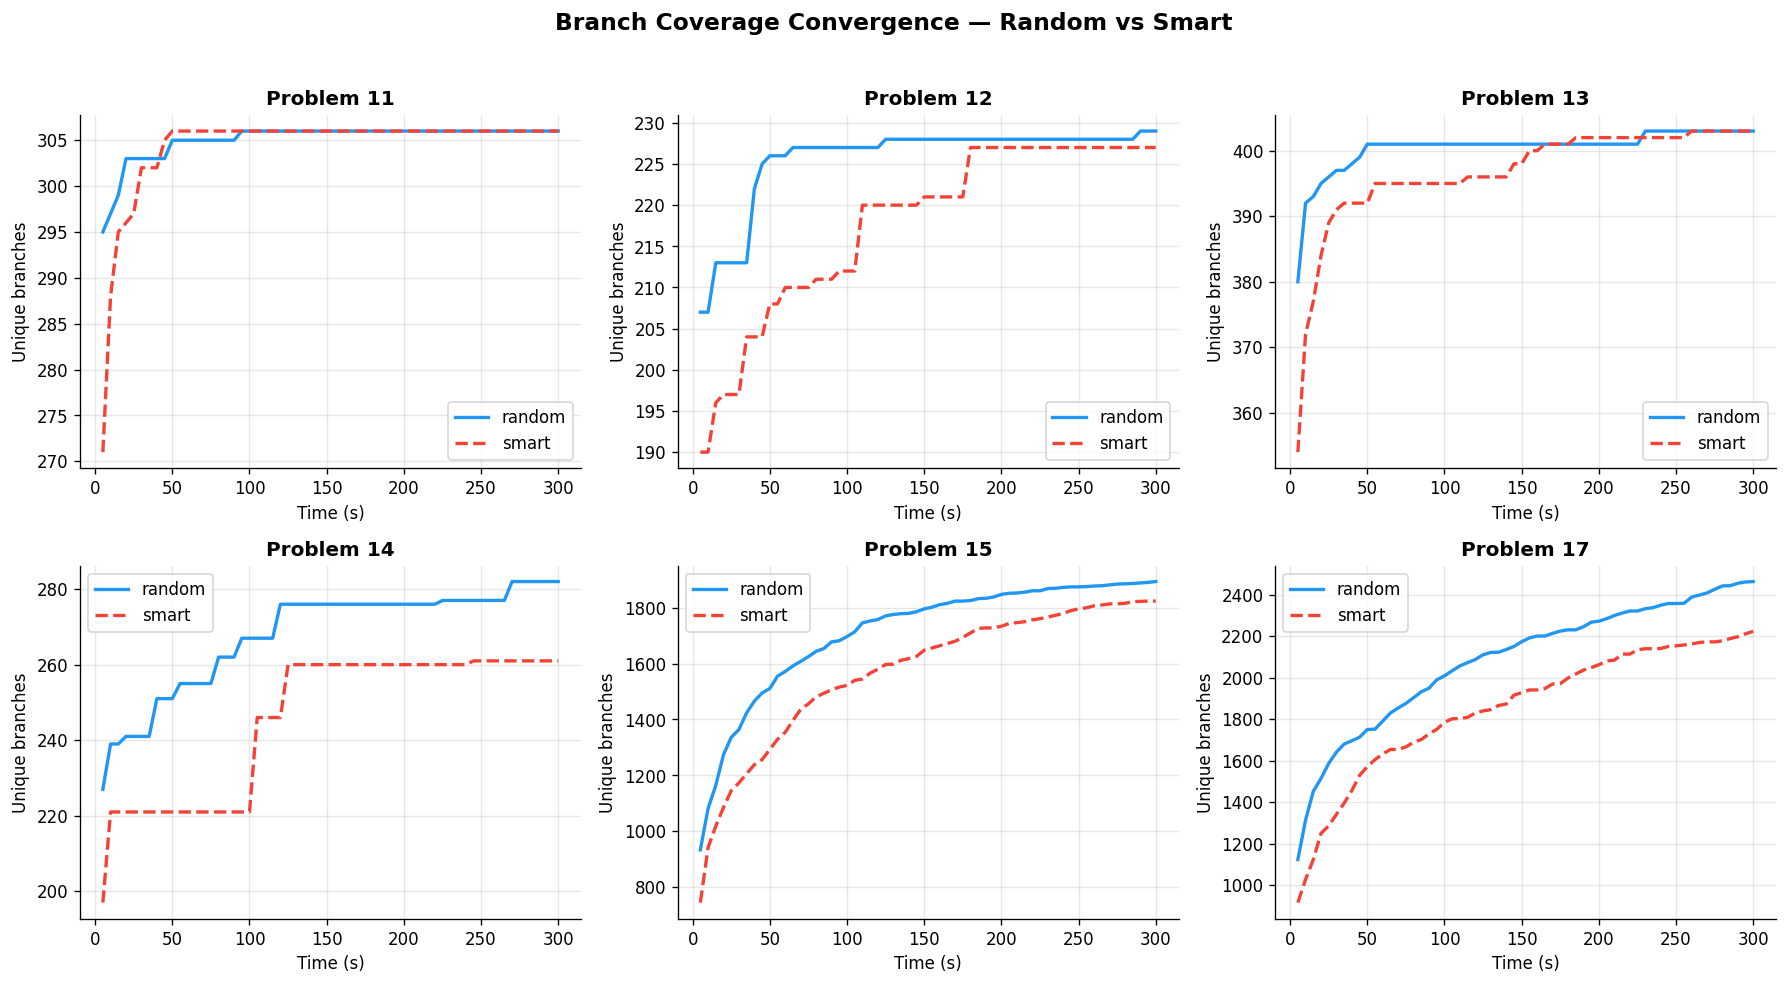

Saved: figures/branch_convergence.png


In [6]:
ncols = 3
nrows = (len(PROBLEMS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, p in enumerate(PROBLEMS):
    ax = axes[idx]
    has_data = False
    for mode in MODES:
        df = branches[(p, mode)]
        if df is not None and not df.empty:
            ax.plot(df['elapsed_seconds'], df['unique_branches'],
                    color=COLORS[mode], ls=LINESTYLES[mode],
                    linewidth=2, label=mode)
            has_data = True
    ax.set_title(f'Problem {p}', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Unique branches')
    ax.legend()
    if not has_data:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes,
                color='grey')

for idx in range(len(PROBLEMS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Branch Coverage Convergence — Random vs Smart', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'branch_convergence.png', bbox_inches='tight')
plt.show()
print('Saved: figures/branch_convergence.png')

## 4 – Error discovery convergence

Each subplot shows the **cumulative number of unique error codes** triggered over time.
Each step represents the first time a new error code was reached.

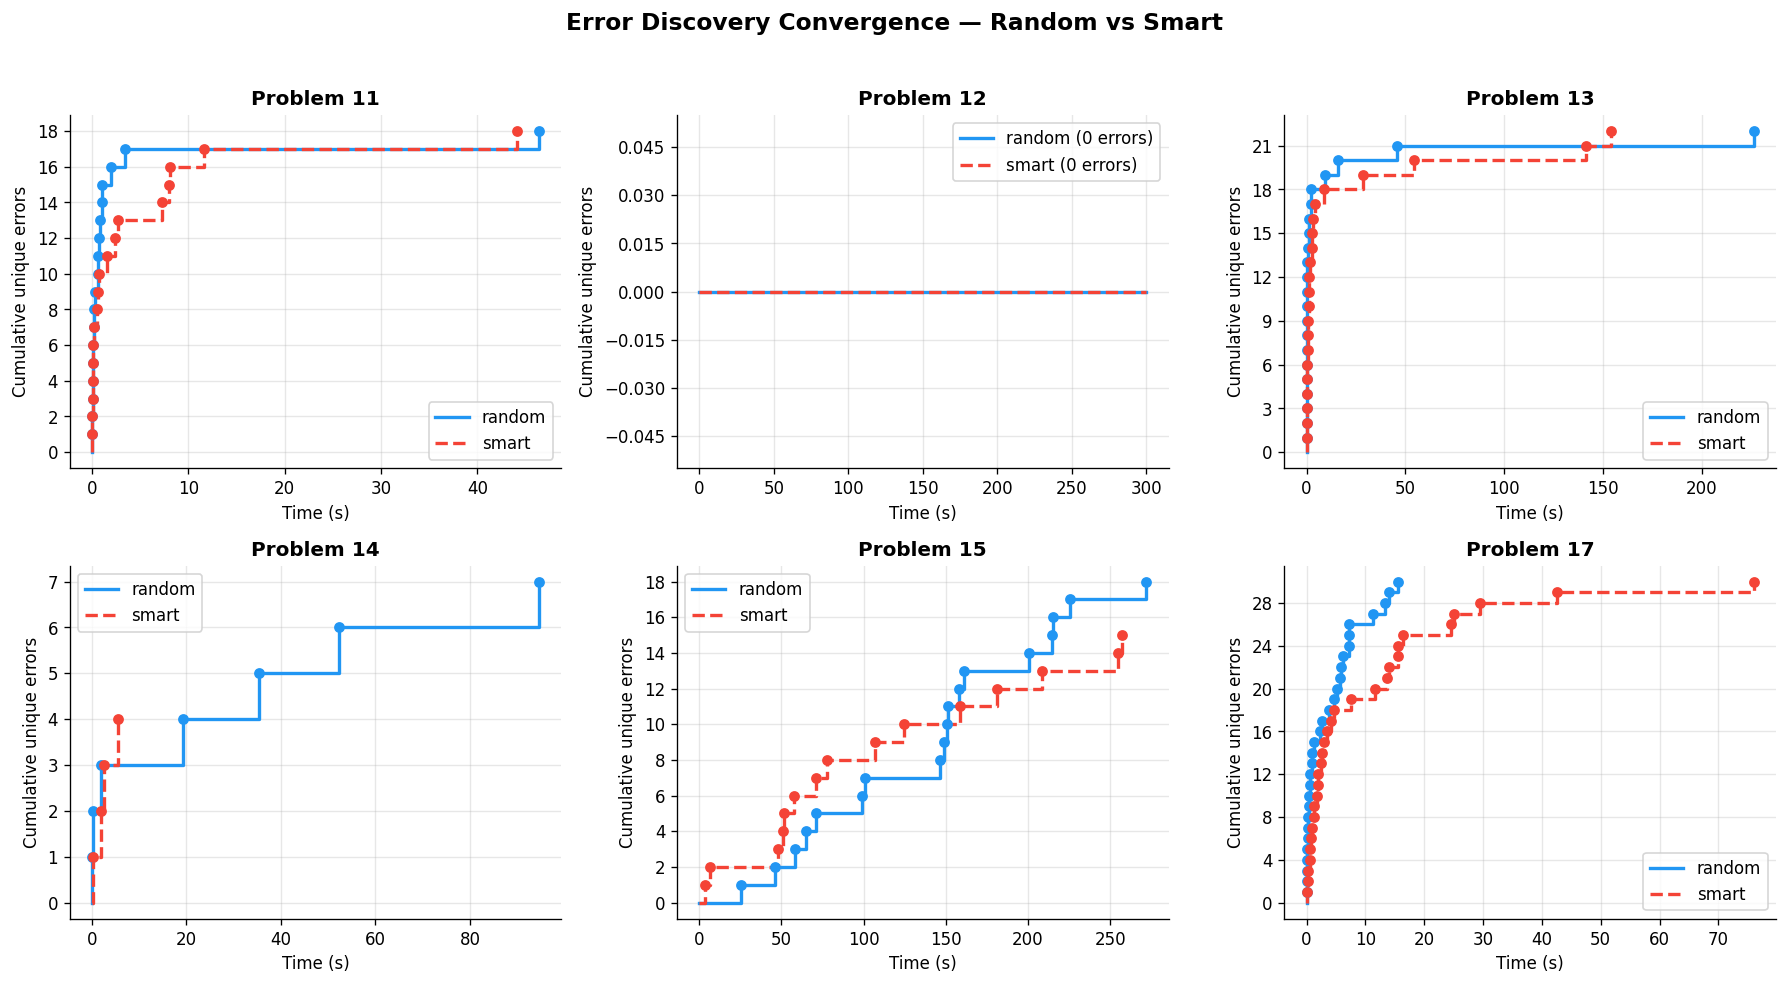

Saved: figures/error_convergence.png


In [7]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, p in enumerate(PROBLEMS):
    ax = axes[idx]
    has_data = False
    for mode in MODES:
        df = errors[(p, mode)]
        # Build step-function: prepend (0, 0) so graph starts at origin
        if df is not None and not df.empty:
            t = [0.0] + list(df['elapsed_seconds'])
            c = [0]   + list(df['cumulative_errors'])
            ax.step(t, c, where='post',
                    color=COLORS[mode], ls=LINESTYLES[mode],
                    linewidth=2, label=mode)
            # Mark each discovery event
            ax.scatter(df['elapsed_seconds'], df['cumulative_errors'],
                       color=COLORS[mode], s=30, zorder=5)
            has_data = True
        elif logs[(p, mode)]['num_errors'] == 0:
            # Flat line at zero
            ax.plot([0, logs[(p, mode)].get('duration', 300)], [0, 0],
                    color=COLORS[mode], ls=LINESTYLES[mode],
                    linewidth=2, label=f'{mode} (0 errors)')
            has_data = True
    ax.set_title(f'Problem {p}', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cumulative unique errors')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend()
    if not has_data:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes,
                color='grey')

for idx in range(len(PROBLEMS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Error Discovery Convergence — Random vs Smart', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'error_convergence.png', bbox_inches='tight')
plt.show()
print('Saved: figures/error_convergence.png')

## 5 – Aggregate comparison bar charts

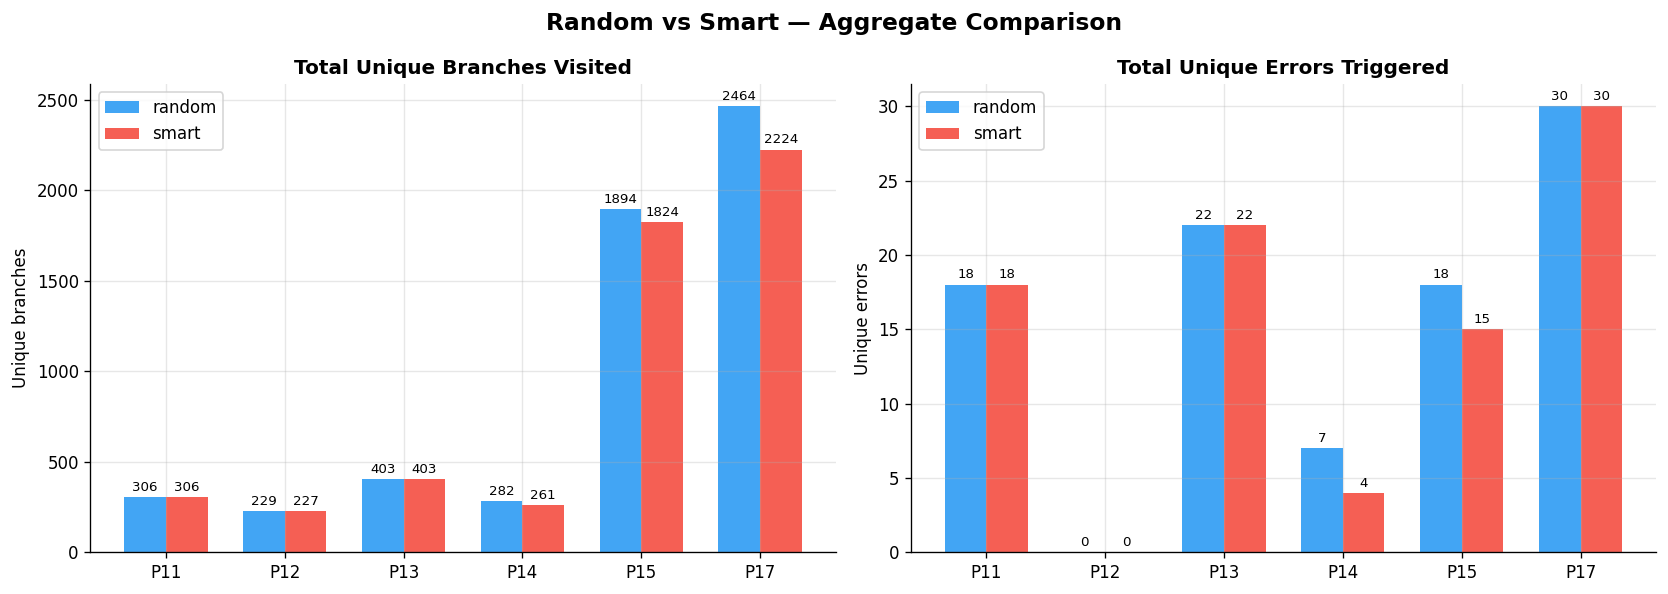

Saved: figures/aggregate_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x        = np.arange(len(PROBLEMS))
width    = 0.35
labels   = [f'P{p}' for p in PROBLEMS]

for ax, metric, ylabel, title in [
    (axes[0], 'total_branches',  'Unique branches',  'Total Unique Branches Visited'),
    (axes[1], 'num_errors',      'Unique errors',    'Total Unique Errors Triggered'),
]:
    for i, mode in enumerate(MODES):
        vals = [logs[(p, mode)][metric] or 0 for p in PROBLEMS]
        bars = ax.bar(x + (i - 0.5) * width, vals, width,
                      label=mode, color=COLORS[mode], alpha=0.85)
        ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()

fig.suptitle('Random vs Smart — Aggregate Comparison', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'aggregate_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: figures/aggregate_comparison.png')

## 6 – Error code detail

Which specific error codes each fuzzer found, and which are exclusive to one mode.

In [9]:
for p in PROBLEMS:
    r_codes = set(logs[(p, 'random')]['error_codes'])
    s_codes = set(logs[(p, 'smart')] ['error_codes'])
    both    = r_codes & s_codes
    r_only  = r_codes - s_codes
    s_only  = s_codes - r_codes
    print(f'Problem {p}')
    print(f'  random ({len(r_codes):2d}): {sorted(r_codes, key=lambda x: int(x.split("_")[1])) or "—"}')
    print(f'  smart  ({len(s_codes):2d}): {sorted(s_codes, key=lambda x: int(x.split("_")[1])) or "—"}')
    if r_only: print(f'  random-only : {sorted(r_only, key=lambda x: int(x.split("_")[1]))}')
    if s_only: print(f'  smart-only  : {sorted(s_only, key=lambda x: int(x.split("_")[1]))}')
    print()

Problem 11
  random (18): ['error_0', 'error_9', 'error_13', 'error_24', 'error_26', 'error_39', 'error_42', 'error_48', 'error_52', 'error_60', 'error_62', 'error_74', 'error_75', 'error_82', 'error_91', 'error_93', 'error_94', 'error_95']
  smart  (18): ['error_0', 'error_9', 'error_13', 'error_24', 'error_26', 'error_39', 'error_42', 'error_48', 'error_52', 'error_60', 'error_62', 'error_74', 'error_75', 'error_82', 'error_91', 'error_93', 'error_94', 'error_95']

Problem 12
  random ( 0): —
  smart  ( 0): —

Problem 13
  random (22): ['error_1', 'error_3', 'error_10', 'error_16', 'error_23', 'error_30', 'error_31', 'error_34', 'error_35', 'error_37', 'error_48', 'error_49', 'error_52', 'error_68', 'error_70', 'error_71', 'error_72', 'error_74', 'error_75', 'error_82', 'error_87', 'error_90']
  smart  (22): ['error_1', 'error_3', 'error_10', 'error_16', 'error_23', 'error_30', 'error_31', 'error_34', 'error_35', 'error_37', 'error_48', 'error_49', 'error_52', 'error_68', 'error_70',

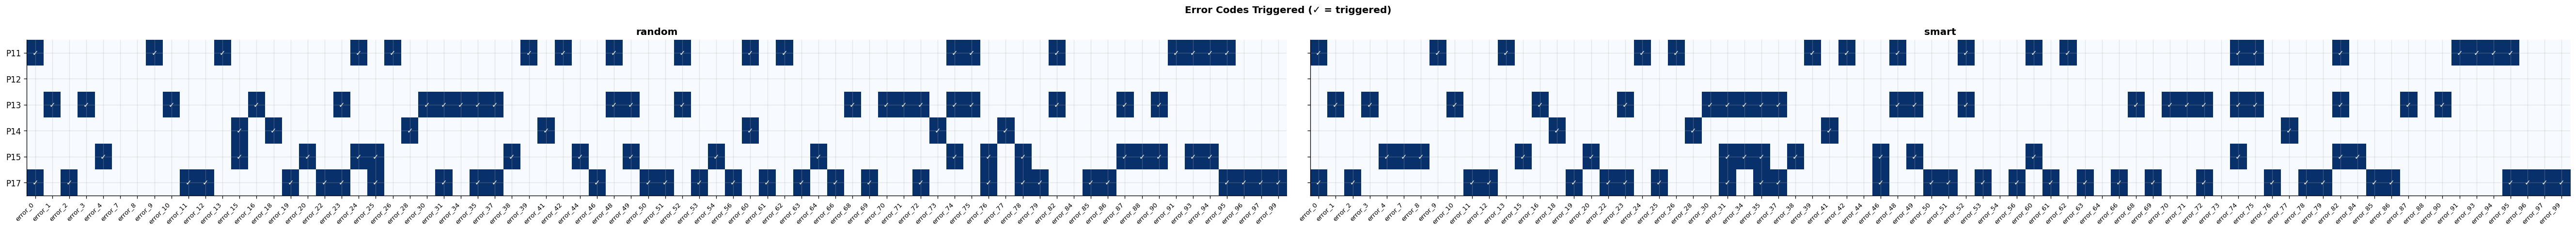

Saved: figures/error_heatmap.png


In [10]:
# Heatmap: which errors were triggered per problem per mode
# Collect all error codes across all problems and modes
all_codes = sorted(
    {c for p in PROBLEMS for m in MODES for c in logs[(p, m)]['error_codes']},
    key=lambda x: int(x.split('_')[1])
)

if all_codes:
    fig, axes = plt.subplots(1, 2, figsize=(max(8, len(all_codes) * 0.6), 4), sharey=True)
    for ax, mode in zip(axes, MODES):
        matrix = pd.DataFrame(
            [[1 if c in logs[(p, mode)]['error_codes'] else 0
              for c in all_codes]
             for p in PROBLEMS],
            index=[f'P{p}' for p in PROBLEMS],
            columns=all_codes
        )
        im = ax.imshow(matrix.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(len(all_codes)))
        ax.set_xticklabels(all_codes, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(PROBLEMS)))
        ax.set_yticklabels([f'P{p}' for p in PROBLEMS])
        ax.set_title(f'{mode}', fontweight='bold')
        # Annotate cells
        for i in range(len(PROBLEMS)):
            for j in range(len(all_codes)):
                if matrix.values[i, j]:
                    ax.text(j, i, '✓', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    fig.suptitle('Error Codes Triggered (✓ = triggered)', fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'error_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Saved: figures/error_heatmap.png')
else:
    print('No error codes found in any result — skipping heatmap.')

## 7 – Best trace per problem

In [11]:
rows = []
for p in PROBLEMS:
    for mode in MODES:
        rows.append({
            'Problem': f'Problem {p}',
            'Mode':    mode,
            'Best run (branches)': logs[(p, mode)]['best_run_branches'],
            'Best trace': logs[(p, mode)]['best_trace'] or '—',
        })
display(pd.DataFrame(rows))

,Problem,Mode,Best run (branches),Best trace
0,Problem 11,random,166,"[J, F, J, E, B, F, J, F, D, D]"
1,Problem 11,smart,164,"[J, F, I, E, J, E, B, F, F, J, G]"
2,Problem 12,random,172,"[E, G, E, C, D, I, F, A, I, B]"
3,Problem 12,smart,166,"[E, D, G, I, H, B, I, F, G, F, A, E]"
4,Problem 13,random,192,"[C, D, H, E, I, H, G, C, F, E]"
5,Problem 13,smart,192,"[G, C, E, I, H, F, C, J, I, H, J]"
6,Problem 14,random,209,"[K, N, C, J, D, N, M, K, L, G]"
7,Problem 14,smart,210,"[F, N, J, C, J, D, M, N, N, D, F, N]"
8,Problem 15,random,241,"[D, A, N, I, J, I, C, M, H, L]"
9,Problem 15,smart,235,"[I, H, I, A, G, D, K, L, N, H]"


## 8 – Convergence speed: time to first N errors

For each problem that triggered at least one error in both modes, compare how quickly the fuzzers
first found 1, 2, 3, … errors.

In [12]:
for p in PROBLEMS:
    dfs = {m: errors[(p, m)] for m in MODES if errors[(p, m)] is not None and not errors[(p, m)].empty}
    if len(dfs) < 2:
        continue
    max_n = max(len(df) for df in dfs.values())
    if max_n == 0:
        continue
    print(f'Problem {p} — time to reach each successive error:')
    rows = []
    for n in range(1, max_n + 1):
        row = {'N-th error': n}
        for mode, df in dfs.items():
            if n <= len(df):
                row[mode] = f"{df.iloc[n-1]['elapsed_seconds']:.1f}s==({df.iloc[n-1]['error_code']})"
            else:
                row[mode] = '—'
        rows.append(row)
    display(pd.DataFrame(rows).set_index('N-th error'))
    print()

Problem 11 — time to reach each successive error:


,random,smart
N-th error,,
1,0.0s==(error_48),0.0s==(error_62)
2,0.0s==(error_62),0.0s==(error_0)
3,0.1s==(error_74),0.1s==(error_74)
4,0.1s==(error_95),0.1s==(error_24)
5,0.1s==(error_60),0.1s==(error_95)
6,0.1s==(error_24),0.1s==(error_93)
7,0.2s==(error_9),0.2s==(error_60)
8,0.2s==(error_0),0.5s==(error_48)
9,0.3s==(error_93),0.6s==(error_75)



Problem 13 — time to reach each successive error:


,random,smart
N-th error,,
1,0.0s==(error_34),0.0s==(error_3)
2,0.1s==(error_10),0.0s==(error_37)
3,0.1s==(error_71),0.1s==(error_34)
4,0.1s==(error_49),0.2s==(error_1)
5,0.1s==(error_37),0.2s==(error_71)
6,0.1s==(error_1),0.3s==(error_10)
7,0.1s==(error_48),0.5s==(error_70)
8,0.1s==(error_30),0.6s==(error_49)
9,0.2s==(error_70),0.7s==(error_75)



Problem 14 — time to reach each successive error:


,random,smart
N-th error,,
1,0.1s==(error_41),0.3s==(error_41)
2,0.2s==(error_77),2.0s==(error_18)
3,1.9s==(error_18),2.6s==(error_77)
4,19.3s==(error_28),5.5s==(error_28)
5,35.3s==(error_15),—
6,52.3s==(error_73),—
7,94.6s==(error_60),—



Problem 15 — time to reach each successive error:


,random,smart
N-th error,,
1,25.2s==(error_64),3.2s==(error_15)
2,45.8s==(error_15),6.7s==(error_20)
3,58.5s==(error_88),47.8s==(error_60)
4,65.2s==(error_76),51.2s==(error_31)
5,71.3s==(error_54),51.6s==(error_34)
6,99.0s==(error_20),57.8s==(error_84)
7,100.7s==(error_87),70.8s==(error_49)
8,146.5s==(error_90),77.5s==(error_7)
9,149.0s==(error_4),106.8s==(error_82)



Problem 17 — time to reach each successive error:


,random,smart
N-th error,,
1,0.0s==(error_53),0.1s==(error_66)
2,0.1s==(error_69),0.2s==(error_78)
3,0.1s==(error_66),0.2s==(error_69)
4,0.1s==(error_11),0.5s==(error_56)
5,0.1s==(error_25),0.6s==(error_99)
6,0.2s==(error_78),0.8s==(error_96)
7,0.2s==(error_2),1.0s==(error_53)
8,0.3s==(error_99),1.2s==(error_61)
9,0.4s==(error_46),1.3s==(error_35)
